# Dataset Preprocessing

## Mount Google Drive & Set Paths

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define base directory where the files are stored
base_path = "/content/drive/MyDrive/QML/validation/"

## Load and Label Files Based on Parent Folder

In [ ]:
import os
import pandas as pd

# File paths (Update these with correct paths)
able_bodied_file = "/content/drive/MyDrive/QML/validation/MAT_normalizedData_AbleBodiedAdults_v06-03-23.xlsx"
post_stroke_file = "/content/drive/MyDrive/QML/validation/MAT_normalizedData_PostStrokeAdults_v27-02-23.xlsx"

# Load Excel files
xls_able = pd.ExcelFile(able_bodied_file)
xls_stroke = pd.ExcelFile(post_stroke_file)

# Get subject sheet names
able_bodied_subjects = xls_able.sheet_names[:50]  # First 50 Able-Bodied
post_stroke_subjects = xls_stroke.sheet_names[:50]  # First 50 Post-Stroke

# Create output folders
os.makedirs("/content/drive/MyDrive/QML/validation/Healthy", exist_ok=True)
os.makedirs("/content/drive/MyDrive/QML/validation/Stroke", exist_ok=True)

In [ ]:
# Function to process and save subject data
def save_subject_data(xls, subject_list, folder, label):
    for subject in subject_list:
        df = pd.read_excel(xls, sheet_name=subject)
        df["Label"] = label  # Assign label (0 = Healthy, 1 = Stroke)
        file_path = os.path.join(folder, f"{subject}.csv")
        df.to_csv(file_path, index=False)

# Process and save Able-Bodied data
save_subject_data(xls_able, able_bodied_subjects, "/content/drive/MyDrive/QML/validation/Healthy", label=0)

# Process and save Post-Stroke data
save_subject_data(xls_stroke, post_stroke_subjects, "/content/drive/MyDrive/QML/validation/Stroke", label=1)

print(f"✅ Processed {len(able_bodied_subjects)} Healthy subjects and {len(post_stroke_subjects)} Stroke subjects.")
print("📁 CSV files saved in 'Healthy/' and 'Stroke/' folders.")

✅ Processed 50 Healthy subjects and 50 Stroke subjects.
📁 CSV files saved in 'Healthy/' and 'Stroke/' folders.


# Feature Extraction


### Setup and Load Pose Data

In [ ]:
import os
import pandas as pd

In [ ]:
# Paths to Healthy & Stroke folders
healthy_folder = "/content/drive/MyDrive/QML/validation/Healthy/"
stroke_folder = "/content/drive/MyDrive/QML/validation/Stroke/"

# Define relevant features
selected_features = [
    "HipAngles", "KneeAngles", "AnkleAngles"  # Joint Angles (common in both datasets)
]

### Define Feature Extraction Functions

In [ ]:
# Function to extract features and rename subjects while keeping Label
def extract_features(folder, label, subject_prefix):
    extracted_data = []
    subject_id = 1  # Unique ID counter

    for file in sorted(os.listdir(folder)):  # Sort files for consistent ordering
        if file.endswith(".csv"):
            file_path = os.path.join(folder, file)
            df = pd.read_csv(file_path)

            # Standardize column names
            df.columns = df.columns.str.strip()

            # Ensure selected features exist
            valid_features = [feat for feat in selected_features if feat in df.columns]
            if not valid_features:
                print(f"⚠️ Warning: No matching features found in {file}!")
                continue

            # Extract relevant columns
            df_selected = df[valid_features].copy()

            # Rename subject to ensure uniqueness (e.g., Healthy_01, Stroke_01)
            df_selected["Subject"] = f"{subject_prefix}_{subject_id:02d}"
            df_selected["Label"] = label  # Ensure label is included

            extracted_data.append(df_selected)
            subject_id += 1  # Increment subject counter

    return pd.concat(extracted_data, ignore_index=True) if extracted_data else pd.DataFrame()

In [ ]:
def apply_windowing_per_subject(df, window_size=12, overlap=6):
    """
    Applies windowing per subject with proper column naming.
    Each window is flattened to a 1D feature vector with names like 'HipAngles_t0', ..., 'AnkleAngles_t11'.
    """
    windowed_rows = []
    column_names = []

    for subject in df["Subject"].unique():
        subject_df = df[df["Subject"] == subject]
        feature_cols = [col for col in subject_df.columns if col not in ["Subject", "Label"]]
        data = subject_df[feature_cols].values
        label = subject_df["Label"].iloc[0]  # Same label for the whole subject

        step = window_size - overlap
        for start in range(0, len(data) - window_size + 1, step):
            window = data[start:start + window_size]
            flattened = window.flatten()
            row = list(flattened) + [label]
            windowed_rows.append(row)

    # Generate proper column names like HipAngles_t0, HipAngles_t1, ..., AnkleAngles_t11
    for t in range(window_size):
        for feat in feature_cols:
            column_names.append(f"{feat}_t{t}")
    column_names.append("Label")

    return pd.DataFrame(windowed_rows, columns=column_names)

### Process Pose Data & Extract Features

In [ ]:
# Extract features and ensure unique naming
df_healthy = extract_features(healthy_folder, label=0, subject_prefix="Healthy")
df_stroke = extract_features(stroke_folder, label=1, subject_prefix="Stroke")

# Combine datasets (raw time-series)
df_combined_raw = pd.concat([df_healthy, df_stroke], ignore_index=True)

# 🪟 Apply windowing before continuing
df_combined = apply_windowing_per_subject(df_combined_raw)

# Save the extracted dataset
output_path = "/content/drive/MyDrive/QML/validation/extracted_gait_features_windowed.csv"
df_combined.to_csv(output_path, index=False)

print(f"✅ Windowed dataset saved: {df_combined.shape[0]} samples, {df_combined.shape[1]} features.")

✅ Windowed dataset saved: 16500 samples, 37 features.


In [ ]:
df_combined.head()

,HipAngles_t0,KneeAngles_t0,AnkleAngles_t0,HipAngles_t1,KneeAngles_t1,AnkleAngles_t1,HipAngles_t2,KneeAngles_t2,AnkleAngles_t2,HipAngles_t3,...,HipAngles_t9,KneeAngles_t9,AnkleAngles_t9,HipAngles_t10,KneeAngles_t10,AnkleAngles_t10,HipAngles_t11,KneeAngles_t11,AnkleAngles_t11,Label
0,30.049283,11.570827,-2.482850,30.037282,11.714903,-2.519216,30.024681,11.858510,-2.555104,30.011461,...,29.917874,12.850300,-2.792050,29.899789,12.990142,-2.823833,29.881429,13.129831,-2.855325,0
1,29.967856,12.428170,-2.693670,29.951934,12.569373,-2.727010,29.935280,12.710084,-2.759807,29.917874,...,29.803088,13.684542,-2.976271,29.781543,13.821460,-3.004636,29.758920,13.957372,-3.032007,0
2,29.862726,13.269265,-2.886438,29.843533,13.408295,-2.917049,29.823703,13.546771,-2.947034,29.803088,...,29.655016,14.491002,-3.131655,29.625860,14.622537,-3.154451,29.595627,14.753186,-3.176210,0
3,29.735071,14.092141,-3.058261,29.709800,14.225834,-3.083470,29.683023,14.358725,-3.107948,29.655016,...,29.465393,15.264074,-3.250358,29.430696,15.388425,-3.265330,29.394712,15.511519,-3.279152,0
4,29.564392,14.882804,-3.196806,29.532227,15.011250,-3.216112,29.499206,15.138379,-3.234003,29.465393,...,29.231656,15.993528,-3.323775,29.186913,16.110906,-3.331378,29.140990,16.226755,-3.337219,0


# Dataset Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [ ]:
# Load the merged dataset
file_path = "/content/drive/MyDrive/QML/validation/extracted_gait_features_windowed.csv"
df = pd.read_csv(file_path)

# Display basic info
print(f"✅ Dataset Loaded: {file_path}")
print(f"🔍 Shape: {df.shape}")
print(f"📝 Columns: {df.columns.tolist()}\n")

✅ Dataset Loaded: /content/drive/MyDrive/QML/validation/extracted_gait_features_windowed.csv
🔍 Shape: (16500, 37)
📝 Columns: ['HipAngles_t0', 'KneeAngles_t0', 'AnkleAngles_t0', 'HipAngles_t1', 'KneeAngles_t1', 'AnkleAngles_t1', 'HipAngles_t2', 'KneeAngles_t2', 'AnkleAngles_t2', 'HipAngles_t3', 'KneeAngles_t3', 'AnkleAngles_t3', 'HipAngles_t4', 'KneeAngles_t4', 'AnkleAngles_t4', 'HipAngles_t5', 'KneeAngles_t5', 'AnkleAngles_t5', 'HipAngles_t6', 'KneeAngles_t6', 'AnkleAngles_t6', 'HipAngles_t7', 'KneeAngles_t7', 'AnkleAngles_t7', 'HipAngles_t8', 'KneeAngles_t8', 'AnkleAngles_t8', 'HipAngles_t9', 'KneeAngles_t9', 'AnkleAngles_t9', 'HipAngles_t10', 'KneeAngles_t10', 'AnkleAngles_t10', 'HipAngles_t11', 'KneeAngles_t11', 'AnkleAngles_t11', 'Label']



In [ ]:
# 1️⃣ Check Class Distribution

# Drop non-numeric columns
df_numeric = df.select_dtypes(include=[np.number])

class_counts = df["Label"].value_counts()
print(f"🎯 Class Distribution:\n{class_counts}\n")

🎯 Class Distribution:
Label
0    8250
1    8250
Name: count, dtype: int64



<ipython-input-25-87e68fd3f7e1>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="Set2")


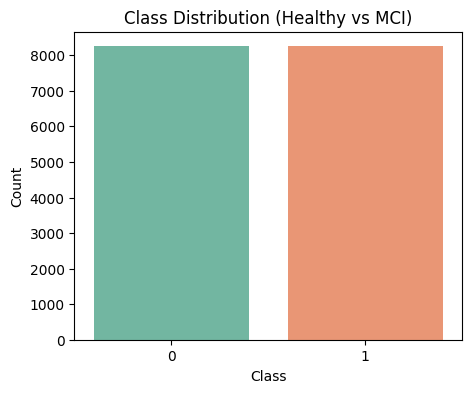

In [ ]:
# Plot class distribution
plt.figure(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="Set2")
plt.title("Class Distribution (Healthy vs MCI)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
# 2️⃣ Check Missing Values
missing_values = df.isnull().sum()
print(f"❌ Missing Values:\n{missing_values[missing_values > 0]}\n")

❌ Missing Values:
Series([], dtype: int64)



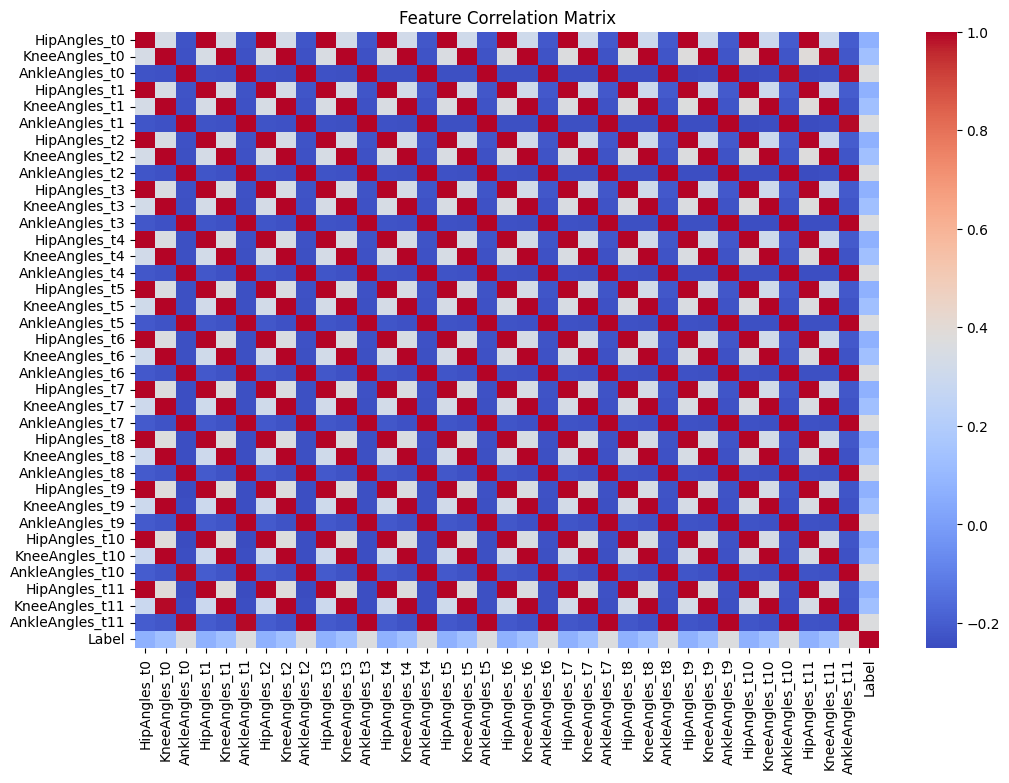

In [ ]:
# 3️⃣ Feature Correlations
plt.figure(figsize=(12, 8))
sns.heatmap(df_numeric.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
# 4️⃣ Detect Outliers using Z-score
z_scores = np.abs(zscore(df_numeric))
outliers = (z_scores > 3).sum()
print(f"⚠️ Outliers Detected in Features:\n{outliers[outliers > 0]}\n")

⚠️ Outliers Detected in Features:
AnkleAngles_t0     126
AnkleAngles_t1     126
AnkleAngles_t2     125
AnkleAngles_t3     124
AnkleAngles_t4     126
AnkleAngles_t5     126
AnkleAngles_t6     126
AnkleAngles_t7     127
AnkleAngles_t8     125
AnkleAngles_t9     125
AnkleAngles_t10    127
AnkleAngles_t11    126
dtype: int64



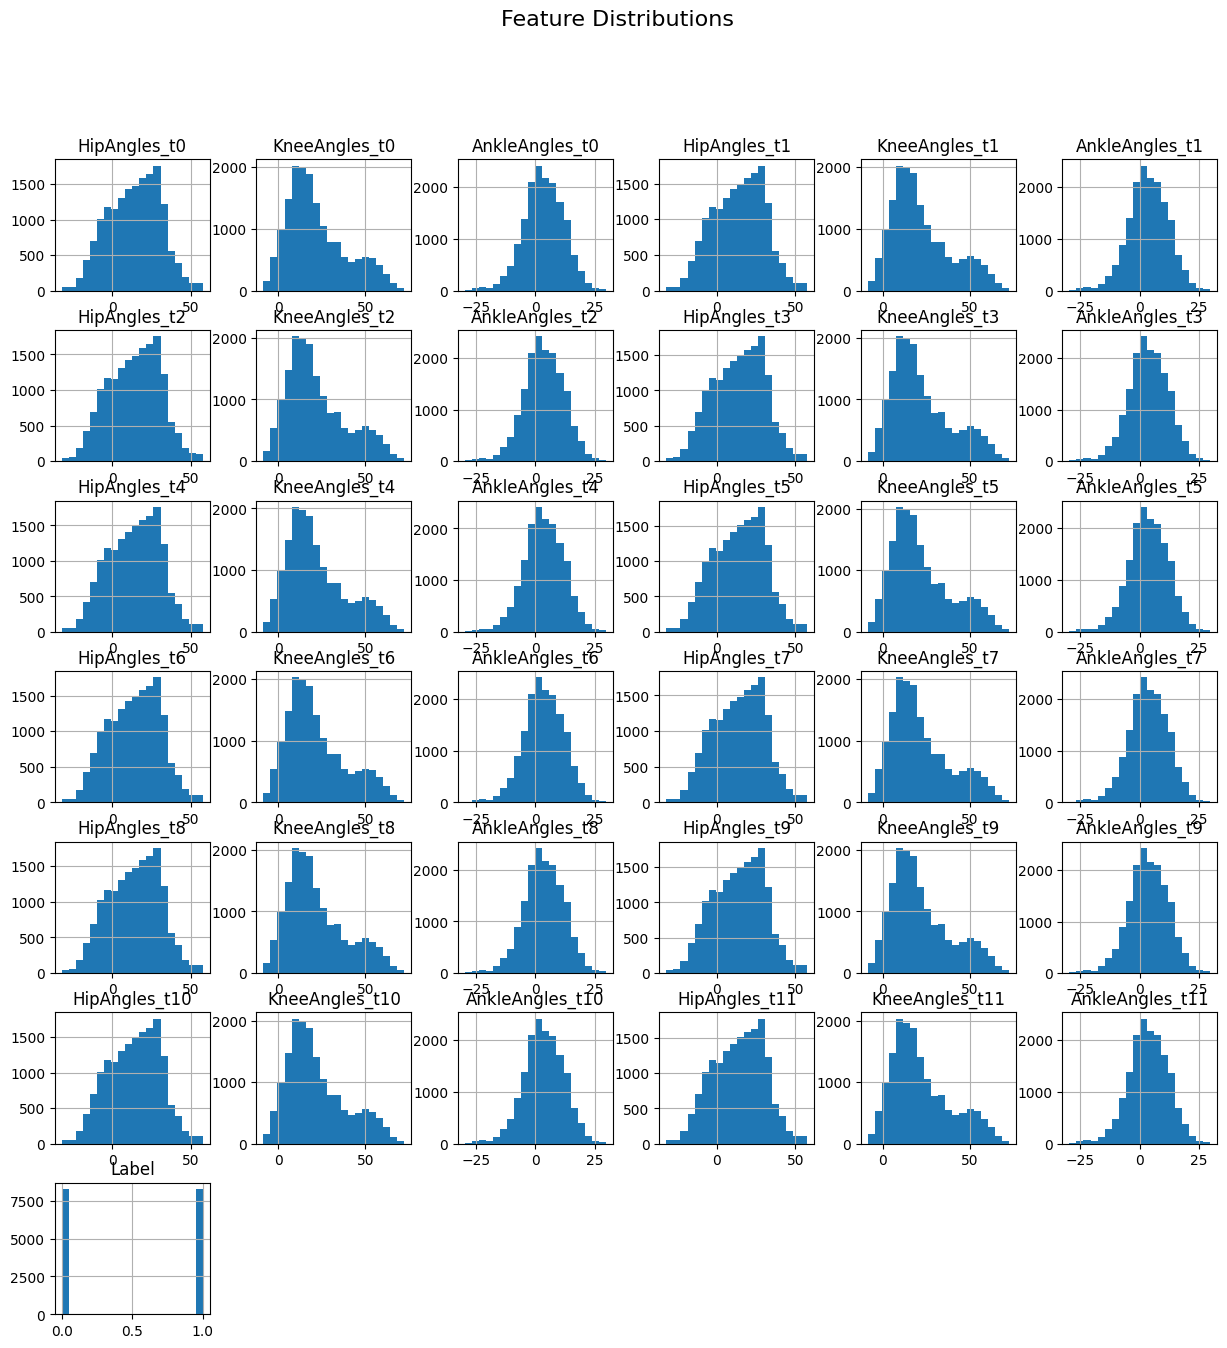

In [ ]:
# Plot feature distributions
df_numeric.hist(figsize=(15, 15), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()